In [2]:
import numpy as np
import pandas as pd
from scipy.stats import linregress, pearsonr

from armored.models import *
from armored.preprocessing import *

import itertools

from tqdm import tqdm

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
species = ['ACabs', 'BAabs', 'BHabs', 'BLabs', 'BUabs', 'CAabs', 'CCabs', 'CHabs',
           'DFabs', 'ELabs', 'ERabs', 'FPabs', 'PCabs', 'PJabs', 'RIabs']
metabolites = ['pH', 'Lactate', 'Butyrate', 'Acetate']
controls = ['AcGum', 'ArGal', 'Inulin', 'Pectin', 'Starch', 'Xylan']

# concatenate all observed and all system variables 
observed = np.concatenate((np.array(species), np.array(metabolites)))
system_variables = np.concatenate((np.array(species), np.array(metabolites), np.array(controls)))

# names of variables
design_vars = [s + " meas" for s in species] + controls

In [3]:
# # predictions for all possible conditions
# pred_df = pd.read_csv("space/space.csv")

# # simulated data
# E_sim = np.array(pred_df.iloc[pred_df.Time.values==0]['Experiments'].values)
# X_sim = np.array(pred_df.iloc[pred_df.Time.values==0][species+controls].values) 
# y_sim = pred_df.iloc[pred_df.Time.values==3]['Objective'].values

# # subsample data 
# subsample_size = 1000
# idx = np.random.choice(len(E_sim), subsample_size, replace=False)
# E = E_sim[idx]
# X = X_sim[idx]
# y = y_sim[idx]

In [4]:
# predictions and measurements for sampled conditions
pred_df = pd.read_csv("space/sampled_space.csv")

import re
def remove_numbers(input_string):
    return re.sub(r'\d', '', input_string)

# experimental data
E = []
X = []
y_meas = []
y_pred = []
for exp, df_exp in pred_df.groupby('Experiments'):
    
    E.append(remove_numbers(exp))
    X.append(df_exp[design_vars].values[0])

    # predicted objective
    y_pred.append(df_exp['Objective pred'].values[-1])
    
    # sometimes measured objective is nan
    if ~np.isnan(df_exp['Objective meas'].values[-1]):
        y_meas.append(df_exp['Objective meas'].values[-1])
    else:
        y_meas.append(np.nan)
        
E = np.array(E)
X = np.array(np.array(X)>0, int)
y_meas = np.array(y_meas)
y_pred = np.array(y_pred)

In [5]:
# data with initial and end point measurements
df_exp0 = pd.read_csv("data/exp0/exp0_metabolites.csv")
df_exp1 = pd.read_csv("data/exp1/exp1_metabolites.csv")
df_exp2 = pd.read_csv("data/exp2/exp2_metabolites.csv")
df_exp3 = pd.read_csv("data/exp3/exp3_metabolites.csv")

E0 = []
for exp, df_exp in df_exp0.groupby('Experiments'):
    E0.append(remove_numbers(exp))
    
E1 = []
for exp, df_exp in df_exp1.groupby('Experiments'):
    E1.append(remove_numbers(exp))

E2 = []
for exp, df_exp in df_exp2.groupby('Experiments'):
    E2.append(remove_numbers(exp))
    
E3 = []
for exp, df_exp in df_exp3.groupby('Experiments'):
    E3.append(remove_numbers(exp))

In [5]:
# E = np.append(E, E_sim)
# X = np.concatenate((X, X_sim), axis=0)
# y = np.append(y_pred, y_sim)

# Dimensionality reduction of design space

In [6]:
# species phylogenetic tree 
tree = ({'ER'}, 
        {'RI'},
        {'CC'}, 
        {'BH'}, 
        {'DF'},
        {'AC'},
        {'FP'},
        {'CH'}, 
        {'CA'}, 
        {'EL'}, 
        {'BA'},
        {'BL'}, 
        {'PJ'}, 
        {'BU'},
        {'PC'},
        {'ER', 'RI'}, 
        {'BH', 'DF'},
        {'CA', 'EL'}, 
        {'BA', 'BL'}, 
        {'BU', 'PC'},
        {'ER', 'RI', 'CC'},
        {'PJ', 'BU', 'PC'},
        {'CA', 'EL', 'BA', 'BL'},
        {'ER', 'RI', 'CC', 'BH', 'DF'},
        {'ER', 'RI', 'CC', 'BH', 'DF', 'AC'},
        {'ER', 'RI', 'CC', 'BH', 'DF', 'AC', 'FP'},
        {'ER', 'RI', 'CC', 'BH', 'DF', 'AC', 'FP', 'CH'},
        {'ER', 'RI', 'CC', 'BH', 'DF', 'AC', 'FP', 'CH', 'CA', 'EL', 'BA', 'BL'})

In [7]:
# vectorize phylogenetic information
Z = np.zeros([len(E), len(tree)])

# experiment name defines species and fiber presence 
for i, exp in enumerate(E):
    for j, node in enumerate(tree):
        # if np.any(np.in1d(list(node), exp.split('-'))):
        # if there's a non-empty intersection 
        if bool(set(node) & set(exp.split('-'))):
            Z[i, j] = 1.

# concatenate phylogentic information with fiber information
M = np.concatenate((Z, X[:,-6:]), -1)

In [8]:
M.shape

(1185, 34)

In [79]:
# # fit tSNE to phylogenetic and fiber information
# from sklearn.manifold import TSNE

# # fit tSNE
# # Initialize t-SNE with recommended hyperparameters
# tsne = TSNE(
#     n_components=2, 
#     perplexity=50, 
#     learning_rate=500, 
#     n_iter=3000, 
#     metric='euclidean', 
#     init='random', 
#     verbose=True
# )
# Y_sub = tsne.fit_transform(M_sub)

In [13]:
# # fit umap 
# import umap

# # Fit UMAP on the original matrix M
# umap_model = umap.UMAP(
#     n_components=2,
#     n_neighbors=500,  
#     min_dist=1.,
#     metric='euclidean', 
#     n_jobs=16,
#     verbose=True
# )
# Y_sub = umap_model.fit_transform(M_sub)

# # compress space
# # Y = umap_model.transform(M)

In [26]:
# # try good ol PCA
# from sklearn.decomposition import PCA
# from sklearn.preprocessing import StandardScaler

# # init and fit
# M_scaled = StandardScaler().fit_transform(M)
# pca = PCA(n_components=2)
# Y = pca.fit_transform(M_scaled)
# explained_variance_ratio = pca.explained_variance_ratio_

In [9]:
# try MDS
from sklearn.manifold import MDS

# # init and fit
mds = MDS(n_components=2, dissimilarity='euclidean')
Y = mds.fit_transform(M)

# Compute the Gram matrix B = -0.5 * H * D^2 * H
D = mds.dissimilarity_matrix_
n = D.shape[0]
H = np.eye(n) - np.ones((n, n)) / n  # Centering matrix
D_squared = D ** 2
B = -0.5 * H @ D_squared @ H

# Perform eigenvalue decomposition on the Gram matrix
eigenvalues, _ = np.linalg.eigh(B)  # eigh() returns sorted eigenvalues

# Sort eigenvalues in descending order
eigenvalues = np.flip(eigenvalues)

# Compute the percent variance explained by the first 2 components
total_variance = np.sum(eigenvalues)
explained_variance_ratio = eigenvalues / total_variance

/home/jcthompson5@ad.wisc.edu/anaconda3/lib/python3.11/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


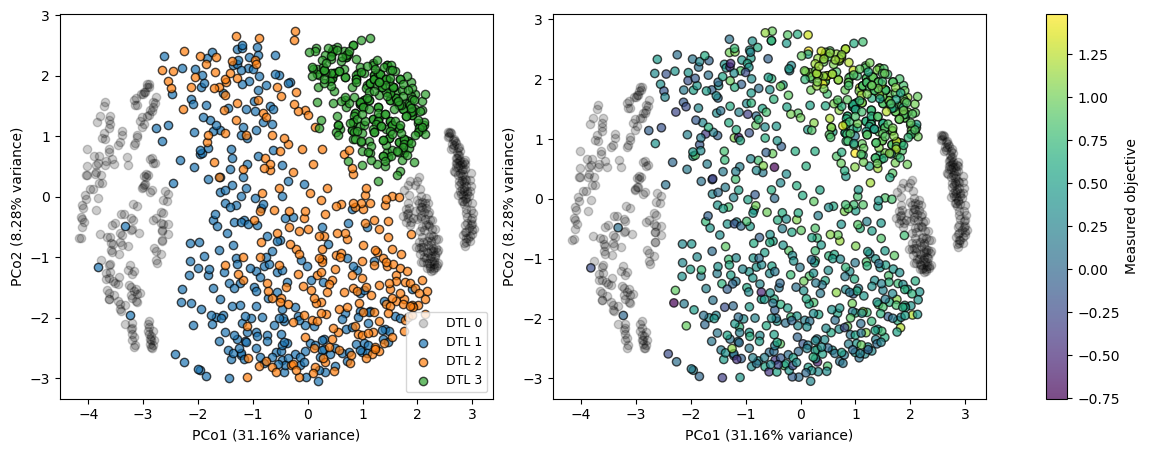

In [10]:
# plot showing traversal through design space
fig = plt.figure(figsize=(13, 5))

# Define a 1-row, 3-column grid, with the last column reserved for the colorbar
gs = GridSpec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.2)

# dtl progression
ax1 = fig.add_subplot(gs[0, 0])

# scatter plot of DTL 0
inds_0 = np.in1d(E, E0)
ax1.scatter(Y[inds_0, 0], Y[inds_0, 1], c='k', edgecolor='k', alpha=.2, label='DTL 0')

# scatter plot of DTL 1
inds_1 = np.in1d(E, E1)
ax1.scatter(Y[inds_1, 0], Y[inds_1, 1], c='C0', edgecolor='k', alpha=.7, label='DTL 1')

# scatter plot of DTL 2
inds_2 = np.in1d(E, E2)
ax1.scatter(Y[inds_2, 0], Y[inds_2, 1], c='C1', edgecolor='k', alpha=.7, label='DTL 2')

# scatter plot of DTL 3
inds_3 = np.in1d(E, E3)
ax1.scatter(Y[inds_3, 0], Y[inds_3, 1], c='C2', edgecolor='k', alpha=.7, label='DTL 3')

# Add explained variance information to axis labels
ax1.legend(fontsize=9)
ax1.set_xlabel(f'PCo1 ({explained_variance_ratio[0]:.2%} variance)')
ax1.set_ylabel(f'PCo2 ({explained_variance_ratio[1]:.2%} variance)')

# objective
ax2 = fig.add_subplot(gs[0, 1])

# scatter plot of nans
inds_nan = np.isnan(y_meas)
ax2.scatter(Y[inds_nan, 0], Y[inds_nan, 1], c='k', edgecolor='k', alpha=.2)

# scatter plot of embedding 
sc = ax2.scatter(Y[:, 0], Y[:, 1], c=y_meas, cmap='viridis', edgecolor='k', alpha=.7)

# Add explained variance information to axis labels
ax2.set_xlabel(f'PCo1 ({explained_variance_ratio[0]:.2%} variance)')
ax2.set_ylabel(f'PCo2 ({explained_variance_ratio[1]:.2%} variance)')

# Add the colorbar without affecting plot sizes
cbar = fig.colorbar(sc, cax=fig.add_subplot(gs[0, 2]))
cbar.set_label('Measured objective')
# plt.savefig('figures/landscapes/mds_presence_absence.png', dpi=300)
# plt.savefig('figures/landscapes/mds_phylogeny_sparse.png', dpi=300)
plt.savefig('figures/landscapes/mds_phylogeny_dtl_objective.svg', dpi=300)
# plt.savefig('figures/landscapes/mds_presence_dtl_objective.png', dpi=300)
plt.show()

In [35]:
# # species phylogenetic tree 
# tree = ({'ER'}, 
#         {'RI'},
#         {'CC'}, 
#         {'BH'}, 
#         {'DF'},
#         {'AC'},
#         {'FP'},
#         {'CH'}, 
#         {'CA'}, 
#         {'EL'}, 
#         {'BA'},
#         {'BL'}, 
#         {'PJ'}, 
#         {'BU'},
#         {'PC'},
#         {'ER', 'RI'}, 
#         {'BH', 'DF'},
#         {'CA', 'EL'}, 
#         {'BA', 'BL'}, 
#         {'BU', 'PC'},
#         {'ER', 'RI', 'CC'},
#         {'PJ', 'BU', 'PC'},
#         {'CA', 'EL', 'BA', 'BL'},
#         {'ER', 'RI', 'CC', 'BH', 'DF'},
#         {'ER', 'RI', 'CC', 'BH', 'DF', 'AC'},
#         {'ER', 'RI', 'CC', 'BH', 'DF', 'AC', 'FP'},
#         {'ER', 'RI', 'CC', 'BH', 'DF', 'AC', 'FP', 'CH'},
#         {'ER', 'RI', 'CC', 'BH', 'DF', 'AC', 'FP', 'CH', 'CA', 'EL', 'BA', 'BL'})



# def unifrac(c1, c2, tree):

#     # count number of unique and total branches
#     unique = 0
#     total = 0

#     # loop over nodes in phylogenetic tree
#     for el in tree:

#         # any shared elements between node and comm1
#         elinC1 = bool(set(el) & set(c1))
        
#         # any shared elements between node and comm2
#         elinC2 = bool(set(el) & set(c2))

#         # exclusive OR to count unique branches
#         unique += int(elinC1 ^ elinC2)

#         # inclusive OR to count unique + shared (total) branches 
#         total += int(elinC1 or elinC2)

#     return unique / total

# # Compute UniFrac dissimilarity
# def dissimilarity(E):
#     n = len(E)
    
#     # Step 1: Compute the distance matrix D (n x n)
#     D = np.zeros((n, n))
#     for i in range(n):
#         for j in range(i + 1, n):
#             D[i, j] = unifrac(set(E[i].split("-")), set(E[j].split("-")), tree)
#             D[j, i] = D[i, j]  # Symmetric matrix
    
#     return D

# # compute distance matrix
# D = dissimilarity(E)

# # MDS using unifrac dissimilarity
# mds = MDS(n_components=2, dissimilarity='precomputed')
# Y = mds.fit_transform(D)
# plot_embedding(Y, y)

In [98]:
# predictions for all possible conditions
# pred_df = pd.read_csv("space/space.csv")

# simulated data
E_sim = np.array(pred_df.iloc[pred_df.Time.values==0]['Experiments'].values)
X_sim = np.array(pred_df.iloc[pred_df.Time.values==0][species+controls].values) 
y_sim = pred_df.iloc[pred_df.Time.values==3]['Butyrate'].values
# y_sim = pred_df.iloc[pred_df.Time.values==3]['Objective'].values

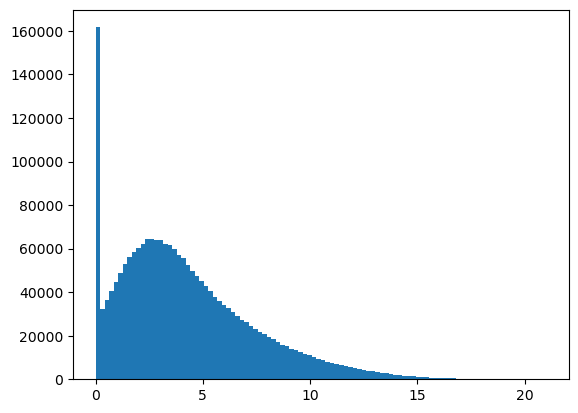

In [99]:
plt.hist(y_sim, bins=100)
plt.show()

In [204]:
np.sum(y_sim>17)

1382

In [205]:
# can we cluster high butyrate producing conditions
high_idx = y_sim>17
E_high = E_sim[high_idx]
X_high = X_sim[high_idx]
y_high = y_sim[high_idx]

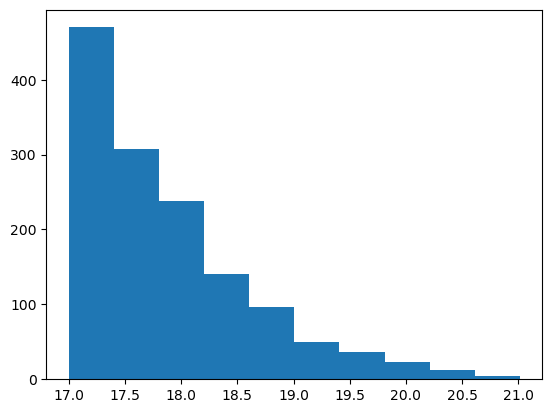

In [206]:
plt.hist(y_high)
plt.show()

In [207]:
# vectorize phylogenetic information
Z_high = np.zeros([len(E_high), len(tree)])

# experiment name defines species and fiber presence 
for i, exp in enumerate(E_high):
    for j, node in enumerate(tree):
        # if np.any(np.in1d(list(node), exp.split('-'))):
        # if there's a non-empty intersection 
        if bool(set(node) & set(exp.split('-'))):
            Z_high[i, j] = 1.

# concatenate phylogentic information with fiber information
M_high = np.concatenate((Z_high, X_high[:, -6:]), -1)

In [150]:
# # add y?
# M_high = np.concatenate((M_high, np.vstack(y_high)), -1)

In [208]:
M_high.shape

(1382, 34)

In [209]:
# try MDS
from sklearn.manifold import MDS

# # init and fit
mds = MDS(n_components=2, dissimilarity='euclidean')
Y_high = mds.fit_transform(M_high)

# Compute the Gram matrix B = -0.5 * H * D^2 * H
D = mds.dissimilarity_matrix_
n = D.shape[0]
H = np.eye(n) - np.ones((n, n)) / n  # Centering matrix
D_squared = D ** 2
B = -0.5 * H @ D_squared @ H

# Perform eigenvalue decomposition on the Gram matrix
eigenvalues, _ = np.linalg.eigh(B)  # eigh() returns sorted eigenvalues

# Sort eigenvalues in descending order
eigenvalues = np.flip(eigenvalues)

# Compute the percent variance explained by the first 2 components
total_variance = np.sum(eigenvalues)
explained_variance_ratio = eigenvalues / total_variance

/home/jcthompson5@ad.wisc.edu/anaconda3/lib/python3.11/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


In [200]:
# # fit tSNE to phylogenetic and fiber information
# from sklearn.manifold import TSNE

# # fit tSNE
# # Initialize t-SNE with recommended hyperparameters
# tsne = TSNE(
#     n_components=2, 
#     perplexity=100, 
#     learning_rate=500, 
#     n_iter=3000, 
#     metric='euclidean', 
#     init='random', 
#     verbose=True
# )
# Y_high = tsne.fit_transform(M_high)

In [210]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=123, n_init="auto").fit(Y_high)
kmeans.labels_

array([1, 1, 1, ..., 0, 0, 0], dtype=int32)

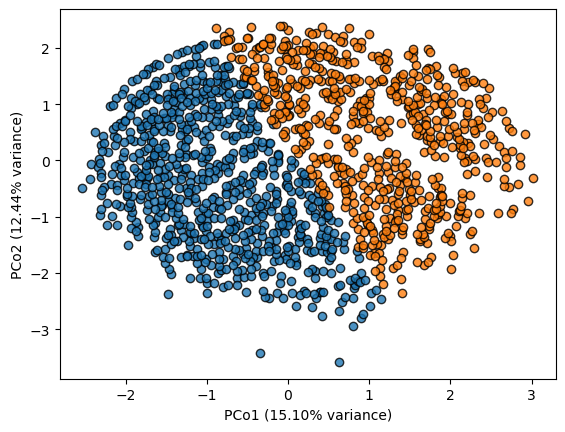

In [211]:
for i in np.unique(kmeans.labels_):

    idx = kmeans.labels_ == i
    plt.scatter(Y_high[idx, 0], Y_high[idx, 1], c=f"C{i}", edgecolor='k', alpha=.8)

# Add explained variance information to axis labels
plt.xlabel(f'PCo1 ({explained_variance_ratio[0]:.2%} variance)')
plt.ylabel(f'PCo2 ({explained_variance_ratio[1]:.2%} variance)')

plt.show()

In [ ]:
# homogeneous variation in communities associated with high butyrate, no obvious clusters

In [212]:
E_high[kmeans.labels_==0]

array(['AC-BU-ER-RI-Starch', 'AC-BU-ER-RI-Starch-Xylan',
       'AC-BU-ER-RI-Inulin-Starch', 'AC-BU-DF-ER-RI-Starch-Xylan',
       'AC-BU-DF-ER-RI-Inulin-Starch', 'AC-BU-CH-Inulin',
       'AC-BU-CH-RI-Inulin', 'AC-BU-CH-ER-RI-Starch-Xylan',
       'AC-BU-CH-ER-RI-Inulin-Starch', 'AC-BU-CH-DF-RI-Inulin',
       'AC-BU-CH-DF-ER-RI-Starch-Xylan', 'AC-BL-ER-PC-RI-Xylan',
       'AC-BL-ER-PC-RI-Starch-Xylan', 'AC-BL-ER-FP-PC-RI-Xylan',
       'AC-BL-ER-FP-PC-RI-Starch-Xylan', 'AC-BL-ER-FP-PC-PJ-RI-Xylan',
       'AC-BL-ER-FP-PC-PJ-RI-Starch-Xylan', 'AC-BL-DF-ER-PC-RI-Xylan',
       'AC-BL-DF-ER-PC-RI-Starch-Xylan', 'AC-BL-DF-ER-FP-PC-RI-Xylan',
       'AC-BL-DF-ER-FP-PC-RI-Starch-Xylan',
       'AC-BL-DF-ER-FP-PC-PJ-RI-Xylan',
       'AC-BL-DF-ER-FP-PC-PJ-RI-Starch-Xylan', 'AC-BL-CH-ER-PC-RI-Xylan',
       'AC-BL-CH-ER-PC-PJ-RI-Xylan', 'AC-BL-CH-ER-FP-PC-RI-Xylan',
       'AC-BL-CH-ER-FP-PC-PJ-Xylan', 'AC-BL-CH-ER-FP-PC-PJ-RI-Xylan',
       'AC-BL-CH-DF-ER-PC-RI-Xylan', 'AC-BL-CH-DF-ER-PC-

In [199]:
E_high[kmeans.labels_==1]

array(['BH-BL-BU-CC-DF-ER-FP-RI-Starch-Xylan', 'AC-CC-CH-ER-RI-Starch',
       'AC-CC-CH-ER-FP-RI-Starch', ...,
       'AC-BA-BH-BL-BU-CA-CC-CH-DF-EL-ER-PJ-RI-Inulin-Starch-Xylan',
       'AC-BA-BH-BL-BU-CA-CC-CH-DF-EL-ER-PJ-RI-Inulin-Pectin-Starch',
       'AC-BA-BH-BL-BU-CA-CC-CH-DF-EL-ER-PJ-RI-Inulin-Pectin-Starch-Xylan'],
      dtype=object)